In [ ]:
##IRIS FLOWER CLASSIFICATION

In [1]:
# ── Standard libraries ──────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn: preprocessing ───────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, LabelEncoder

# ── Sklearn: models ──────────────────────────────────
from sklearn.tree         import DecisionTreeClassifier
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm          import SVC

# ── Sklearn: evaluation ──────────────────────────────
from sklearn.metrics import (accuracy_score,
                              classification_report,
                              confusion_matrix)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ── Load YOUR IRIS.csv file ──────────────────────────
df = pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\python\\IRIS.csv')

print("Dataset Shape  :", df.shape)
print("Column Names   :", list(df.columns))
print("Species Labels :", df['species'].unique().tolist())
print("\n── First 5 Rows ──────────────────────────────")
print(df.head())

Dataset Shape  : (150, 5)
Column Names   : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Species Labels : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

── First 5 Rows ──────────────────────────────
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [3]:
print("── Dataset Info ──────────────────────────────")
df.info()

print("\n── Missing Values ────────────────────────────")
print(df.isnull().sum())

print("\n── Class Distribution ────────────────────────")
print(df['species'].value_counts())

print("\n── Statistical Summary ───────────────────────")
print(df.describe())

── Dataset Info ──────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

── Missing Values ────────────────────────────
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

── Class Distribution ────────────────────────
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

── Statistical Summary ───────────────────────
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.7586

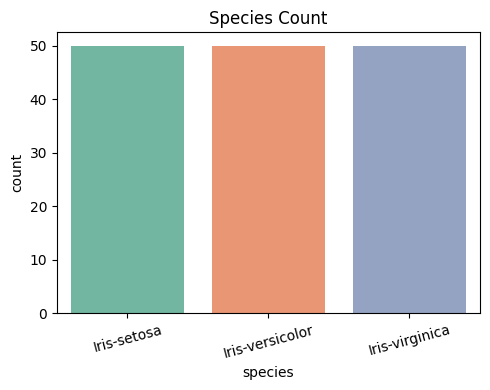

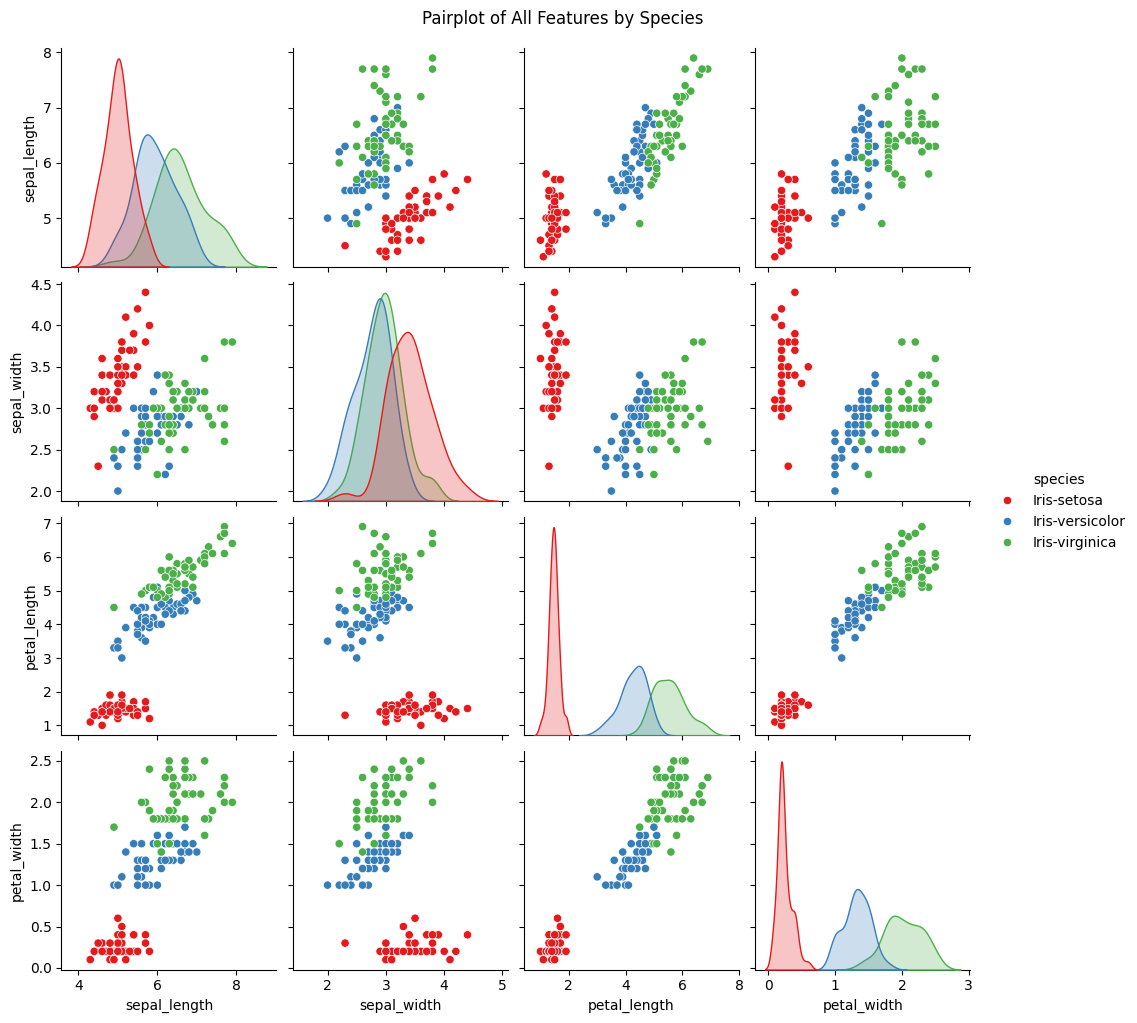

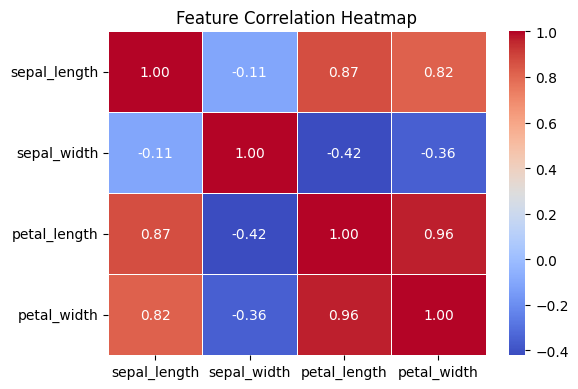

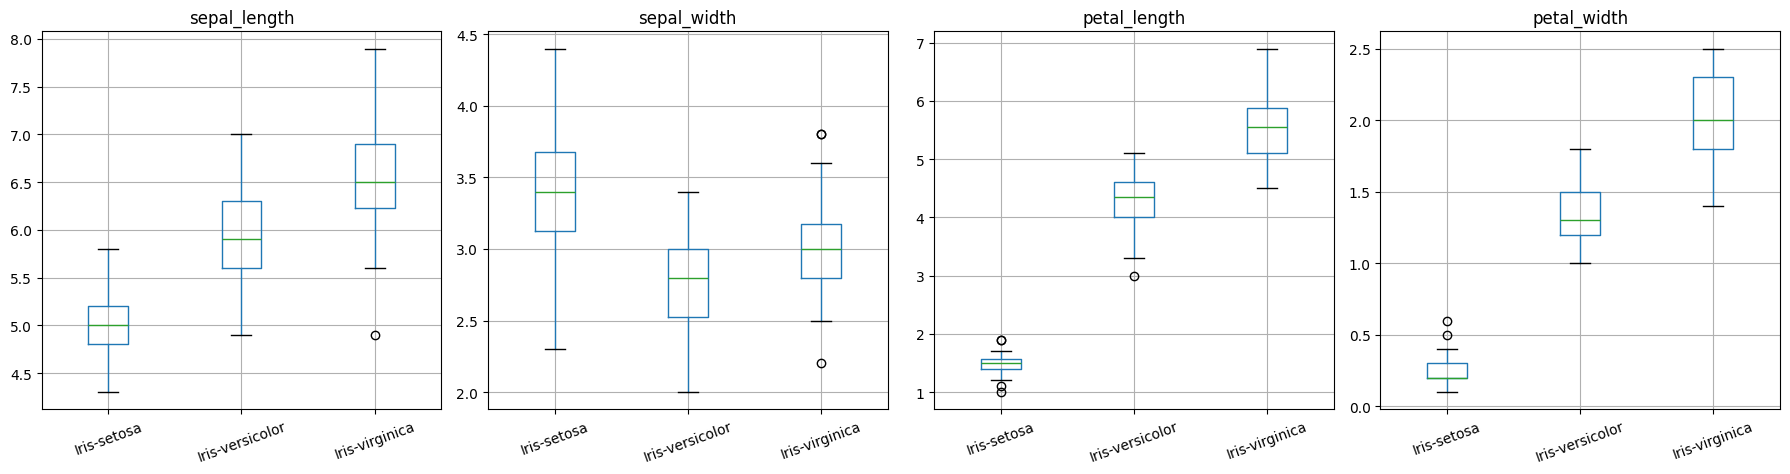

In [4]:
# ── Plot 1: Species count ────────────────────────────
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='species', palette='Set2')
plt.title('Species Count')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

# ── Plot 2: Pairplot ─────────────────────────────────
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle('Pairplot of All Features by Species', y=1.02)
plt.show()

# ── Plot 3: Correlation heatmap ──────────────────────
plt.figure(figsize=(6, 4))
numeric_df = df.drop('species', axis=1)
sns.heatmap(numeric_df.corr(), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout(); plt.show()

# ── Plot 4: Boxplots for all features ────────────────
features = ['sepal_length','sepal_width',
            'petal_length','petal_width']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by='species', ax=ax)
    ax.set_title(feat); ax.set_xlabel('')
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(20)
plt.suptitle(''); plt.tight_layout(); plt.show()

In [5]:
# ── Separate features and target ─────────────────────
X = df.drop('species', axis=1).values
y = df['species'].values

# ── Encode string labels → integers ──────────────────
# Iris-setosa→0, Iris-versicolor→1, Iris-virginica→2
le = LabelEncoder()
y  = le.fit_transform(y)
print("Label Mapping:",
      dict(zip(le.classes_, le.transform(le.classes_))))

# ── Train/Test split: 80% / 20% ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── Feature Scaling ───────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features         : {X_train.shape[1]}")
print("\nPreprocessing complete!")

Label Mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}

Training samples : 120
Testing  samples : 30
Features         : 4

Preprocessing complete!


In [6]:
#Define all four models ───────────────────────────
models = {
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=200),
    'SVM'                : SVC(kernel='rbf', random_state=42)
}

# ── Train and evaluate each model ────────────────────
results = {}
print(f"{'Model':25} {'Accuracy':>10}")
print("─" * 37)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    results[name] = {'model'  : model,
                     'y_pred' : y_pred,
                     'accuracy': acc}
    print(f"{name:25} {acc*100:>9.2f}%")
print("─" * 37)

Model                       Accuracy
─────────────────────────────────────
Decision Tree                 90.00%
KNN                           93.33%
Logistic Regression           93.33%
SVM                           96.67%
─────────────────────────────────────


In [7]:
for name, res in results.items():
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(classification_report(
        y_test, res['y_pred'],
        target_names=le.classes_))


  Decision Tree
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


  KNN
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


  Logistic Regression
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.

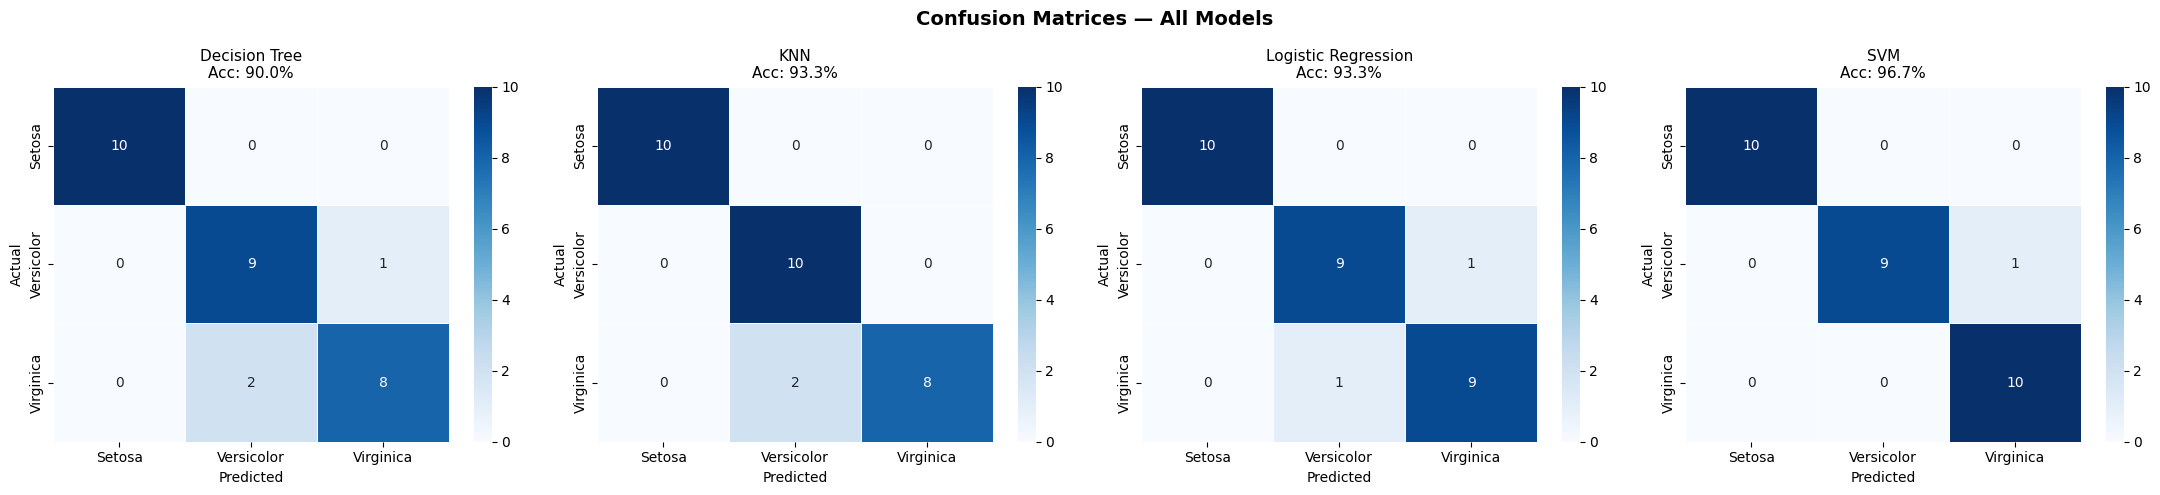

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm,
                annot=True, fmt='d',
                xticklabels=['Setosa','Versicolor','Virginica'],
                yticklabels=['Setosa','Versicolor','Virginica'],
                cmap='Blues', ax=ax, linewidths=.5)
    ax.set_title(
        f"{name}\nAcc: {res['accuracy']*100:.1f}%",
        fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

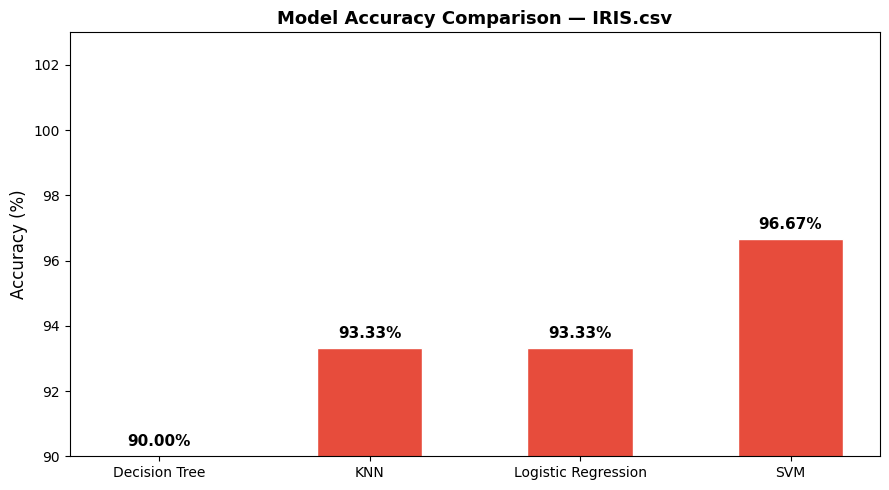


── Final Comparison Table ──────────────────────
              Model Accuracy Result
      Decision Tree   90.00%   GOOD
                KNN   93.33%   GOOD
Logistic Regression   93.33%   GOOD
                SVM   96.67%   GOOD


In [11]:
names  = list(results.keys())
accs   = [res['accuracy'] * 100 for res in results.values()]
colors = ['#2ecc71' if a == 100 else '#e74c3c' for a in accs]

plt.figure(figsize=(9, 5))
bars = plt.bar(names, accs, color=colors,
               edgecolor='white', width=0.5)
plt.ylim(90, 103)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison — IRIS.csv',
          fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Summary Table ─────────────────────────────────────
print("\n── Final Comparison Table ──────────────────────")
summary = pd.DataFrame({
    'Model'    : names,
    'Accuracy' : [f'{a:.2f}%' for a in accs],
    'Result'   : ['PASS' if a==100 else 'GOOD' for a in accs]
})
print(summary.to_string(index=False))

In [13]:
# ── User Input Prediction ────────────────────────────
# This cell will pause and ask you to type each value

print("───────────────────────────────────────────────")
print("   IRIS FLOWER SPECIES PREDICTOR")
print("   Enter the measurements of your flower below")
print("───────────────────────────────────────────────")

# ── Take input from user ─────────────────────────────
sepal_length = float(input("Enter Sepal Length (cm) [e.g. 5.1] : "))
sepal_width  = float(input("Enter Sepal Width  (cm) [e.g. 3.5] : "))
petal_length = float(input("Enter Petal Length (cm) [e.g. 1.4] : "))
petal_width  = float(input("Enter Petal Width  (cm) [e.g. 0.2] : "))

# ── Scale the input ──────────────────────────────────
new_input  = np.array([[sepal_length, sepal_width,
                        petal_length, petal_width]])
new_scaled = scaler.transform(new_input)

# ── Predict using SVM ────────────────────────────────
final_model  = results['SVM']['model']
pred_index   = final_model.predict(new_scaled)[0]
pred_species = le.inverse_transform([pred_index])[0]

# ── Display result ───────────────────────────────────
print("\n───────────────────────────────────────────────")
print("   PREDICTION RESULT")
print("───────────────────────────────────────────────")
print(f"   Sepal Length  : {sepal_length} cm")
print(f"   Sepal Width   : {sepal_width} cm")
print(f"   Petal Length  : {petal_length} cm")
print(f"   Petal Width   : {petal_width} cm")
print("───────────────────────────────────────────────")
print(f"   Predicted Species : {pred_species}")
print("───────────────────────────────────────────────")

───────────────────────────────────────────────
   IRIS FLOWER SPECIES PREDICTOR
   Enter the measurements of your flower below
───────────────────────────────────────────────

───────────────────────────────────────────────
   PREDICTION RESULT
───────────────────────────────────────────────
   Sepal Length  : 5.1 cm
   Sepal Width   : 3.5 cm
   Petal Length  : 1.4 cm
   Petal Width   : 0.2 cm
───────────────────────────────────────────────
   Predicted Species : Iris-setosa
───────────────────────────────────────────────
